# upperlimit

In [1]:
source /export/ciao/bin/ciao.bash -o
PFILES="./param;$ASCDS_INSTALL/param:$ASCDS_INSTALL/contrib/param"
mkdir -p ./param
ASCDS_WORK_PATH=./


CIAO configuration is complete... 
The CIAO setup for this window has changed from
CIAO 4.9 Friday, December  2, 2016
  bindir      : /export/ciao-4.9/bin
  CALDB       : 4.7.3
To:
CIAO 4.9 Friday, December  2, 2016
  bindir      : /export/ciao-4.9/bin
  CALDB       : 4.7.3


In [2]:
/bin/rm -rf 315 
download_chandra_obsid 315
chandra_repro 315 out=`pwd` clob+


  Type     Format      Size  0........H.........1  Download Time Average Rate
  ---------------------------------------------------------------------------
  readme   ascii      10 Kb  ####################          < 1 s  1831.6 kb/s
  oif      fits       25 Kb  ####################          < 1 s  3844.0 kb/s
  vv       pdf        43 Kb  ####################          < 1 s  5677.9 kb/s
  cntr_img fits      258 Kb  ####################          < 1 s  22278.1 kb/s
  cntr_img jpg       656 Kb  ####################          < 1 s  40574.9 kb/s
  evt2     fits       23 Mb  ####################          < 1 s  74747.3 kb/s
  full_img fits       79 Kb  ####################          < 1 s  8197.2 kb/s
  full_img jpg        48 Kb  ####################          < 1 s  4895.2 kb/s
  src2     fits       22 Kb  ####################          < 1 s  3549.2 kb/s
  src_img  jpg        49 Kb  ####################          < 1 s  6025.2 kb/s
  bpix     fits       10 Kb  ####################          <

## Display in ds9

[1] 21849
[1]+  Done                    ds9 acisf00315_repro_evt2.fits -pan to 4200 3850 physical -scale log


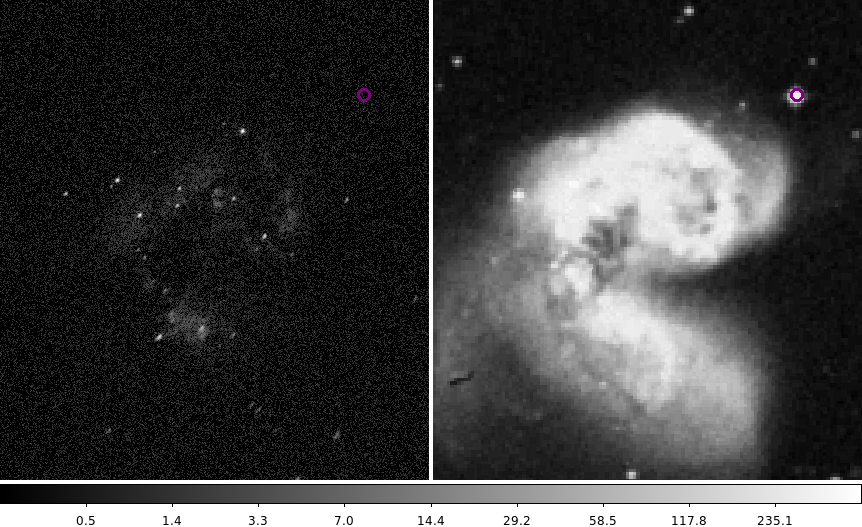

In [3]:
ds9 acisf00315_repro_evt2.fits \
  -pan to 4200 3850 physical \
  -scale log &

sleep 3

xpaset -p ds9 cmap grey
echo "fk5; circle point 12:01:47.9 -18:51:15.6 # color=purple width=3" | xpaset ds9 regions

xpaset -p ds9 dsssao 
xpaset -p ds9 dsssao close
xpaset -p ds9 scale linear
echo "fk5; circle point 12:01:47.9 -18:51:15.6 # color=purple width=3" | xpaset ds9 regions
xpaset -p ds9 frame first
xpaset -p ds9 match frame wcs

xpaset -p ds9 saveimage png ds9_01.png
xpaset -p ds9 quit

display < ds9_01.png



## Run srcflux

In [4]:
punlearn srcflux
pset srcflux infile=acisf00315_repro_evt2.fits
pset srcflux outroot=dss
pset srcflux pos="12:01:47.9 -18:51:15.6"
pset srcflux psfmethod=quick
srcflux mode=h clob+

srcflux
          infile = acisf00315_repro_evt2.fits
             pos = 12:01:47.9 -18:51:15.6
         outroot = dss
           bands = broad
          srcreg = 
          bkgreg = 
         bkgresp = yes
       psfmethod = quick
         psffile = 
            conf = 0.9
         binsize = 1
         rmffile = 
         arffile = 
           model = xspowerlaw.pow1
       paramvals = pow1.PhoIndex=2.0
        absmodel = xsphabs.abs1
       absparams = abs1.nH=%GAL%
           abund = angr
         fovfile = 
        asolfile = 
         mskfile = 
        bpixfile = 
         dtffile = 
         ecffile = CALDB
        parallel = yes
           nproc = INDEF
          tmpdir = ./
         clobber = yes
         verbose = 1
            mode = h

Processing OBI 000
Extracting counts
Getting net rate and confidence limits
Getting model independent fluxes 
Getting model fluxes 
Getting photon fluxes 
Running tasks in parallel with 4 processors.
Making response files for dss_0001
Running

In [5]:
dmlist "dss_broad.flux[cols counts,bg_counts,area,bg_area,net_rate_aper_hi]"  data,clean

#  COUNTS               BG_COUNTS            AREA                 BG_AREA              NET_RATE_APER_HI
                  1.0                 21.0             20.31250             491.1250          5.31102E-05


## Step-by-Step

### 1. Select Apertures

In [6]:
cat << EOM > src.reg
circle(12:01:47.9,-18:51:15.6,5")
EOM

In [7]:
cat << EOM > bkg.reg
annulus(12:01:47.9,-18:51:15.6,5",15")
EOM

### 2. Counts in src and bkg regions

In [8]:
n=`dmlist 'acisf00315_repro_evt2.fits[energy=500:7000][sky=region(src.reg)]' counts`
echo $n

15


In [9]:
m=`dmlist 'acisf00315_repro_evt2.fits[energy=500:7000][sky=region(bkg.reg)]' counts`
echo $m

132


### 3. Area

In [10]:
A_s=`echo '5*5*3.141592' | bc -l`
echo $A_s

78.539800


In [11]:
A_b=`echo '(15*15-5*5)*3.141592' | bc -l`
echo $A_b

628.318400


### 4. Exposure Time

In [12]:
T=` dmkeypar acisf00315_repro_evt2.fits LIVETIME echo+`
echo $T

72242.199605928


### 5. Run aprates

In [13]:
punlearn aprates
pset aprates n=$n m=$m
pset aprates A_s=$A_s A_b=$A_b
pset aprates T_s=$T T_b=$T
pset aprates alpha=1.0 beta=0.0
pset aprates conf=0.68
pset aprates outfile=ulimit.par
aprates mode=h clob+

In [14]:
pget ulimit.par src_rate src_rate_err_lo src_rate_err_up

0
INDEF
5.775e-05


# Cleanup


In [ ]:
/bin/rm -rf 315 
/bin/rm -f acisf* pcadf* 